<a href="https://colab.research.google.com/github/aiska28/Data-Maining/blob/main/Restaurant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Restaurant.csv to Restaurant.csv


In [2]:
import os
os.listdir()

['.config', 'Restaurant.csv', 'sample_data']

In [3]:
import pandas as pd

Restaurant = pd.read_csv('Restaurant.csv')
Restaurant.head()

,BROOKLYN,Chinese,Z
0,MANHATTAN,American,C
1,BRONX,Chicken,C
2,MANHATTAN,American,A
3,MANHATTAN,American,A
4,MANHATTAN,American,C


In [4]:
!pip install mlxtend

In [5]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [19]:
transactions = Restaurant.values.tolist()

# hapus nilai kosong (NaN)
transactions = [[item for item in row if pd.notna(item)] for row in transactions]

In [20]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_data, columns=te.columns_)

df.head()

,A,Afghan,African,American,Armenian,Asian,Australian,B,BRONX,BROOKLYN,...,Southwestern,Spanish,Steak,Tapas,Tex-Mex,Thai,Turkish,Vegetarian,Vietnamese/Cambodian/Malaysia,Z
0,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [21]:
from mlxtend.frequent_patterns import fpgrowth

frequent_fp = fpgrowth(df, min_support=0.02, use_colnames=True)
frequent_fp = frequent_fp.sort_values(by='support', ascending=False)

frequent_fp

,support,itemsets
4,0.513081,( A)
0,0.412647,( MANHATTAN )
6,0.283887,( B)
1,0.239164,( American )
11,0.232744,( BROOKLYN )
13,0.227080,( QUEENS )
20,0.214806,"( A, MANHATTAN )"
2,0.156340,( C)
22,0.134402,"( A, American )"
21,0.129867,"( American , MANHATTAN )"


In [22]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_fp, metric="confidence", min_threshold=0.3)
rules = rules.sort_values(by='confidence', ascending=False)

rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
23,( Cafe/Coffee/Tea ),( A),0.032120,0.513081,0.022016,0.685432,1.335915,1.0,0.005536,1.547899,0.259794,0.042081,0.353963,0.364171
25,( STATENISLAND ),( A),0.032326,0.513081,0.021026,0.650430,1.267696,1.0,0.004440,1.392910,0.218222,0.040097,0.282079,0.345705
20,( Italian ),( MANHATTAN ),0.047672,0.412647,0.029394,0.616597,1.494248,1.0,0.009723,1.531946,0.347325,0.068212,0.347235,0.343915
2,( American ),( A),0.239164,0.513081,0.134402,0.561963,1.095273,1.0,0.011691,1.111595,0.114329,0.217533,0.100392,0.411957
10,"( American , MANHATTAN )",( A),0.129867,0.513081,0.072642,0.559359,1.090197,1.0,0.006010,1.105025,0.095083,0.127374,0.095043,0.350470
21,"( American , BROOKLYN )",( A),0.045329,0.513081,0.025238,0.556769,1.085150,1.0,0.001980,1.098569,0.082194,0.047335,0.089725,0.302979
24,"( QUEENS , American )",( A),0.040071,0.513081,0.022000,0.549014,1.070035,1.0,0.001440,1.079678,0.068183,0.041419,0.073798,0.295946
3,( American ),( MANHATTAN ),0.239164,0.412647,0.129867,0.543003,1.315904,1.0,0.031177,1.285246,0.315529,0.248814,0.221939,0.428860
18,"( American , B)",( MANHATTAN ),0.061208,0.412647,0.033228,0.542860,1.315556,1.0,0.007970,1.284843,0.255504,0.075410,0.221695,0.311691
8,"( A, American )",( MANHATTAN ),0.134402,0.412647,0.072642,0.540487,1.309805,1.0,0.017182,1.278208,0.273253,0.153123,0.217655,0.358263


In [24]:
rules[['antecedents','consequents','support','confidence','lift']]

,antecedents,consequents,support,confidence,lift
23,( Cafe/Coffee/Tea ),( A),0.022016,0.685432,1.335915
25,( STATENISLAND ),( A),0.021026,0.650430,1.267696
20,( Italian ),( MANHATTAN ),0.029394,0.616597,1.494248
2,( American ),( A),0.134402,0.561963,1.095273
10,"( American , MANHATTAN )",( A),0.072642,0.559359,1.090197
21,"( American , BROOKLYN )",( A),0.025238,0.556769,1.085150
24,"( QUEENS , American )",( A),0.022000,0.549014,1.070035
3,( American ),( MANHATTAN ),0.129867,0.543003,1.315904
18,"( American , B)",( MANHATTAN ),0.033228,0.542860,1.315556
8,"( A, American )",( MANHATTAN ),0.072642,0.540487,1.309805


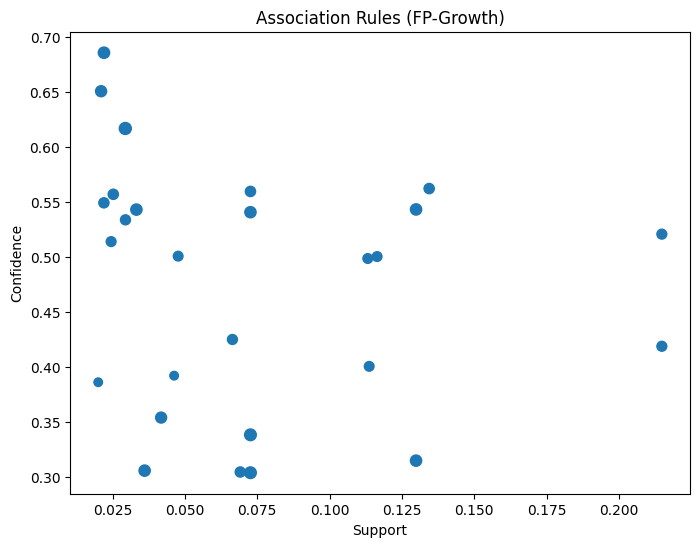

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(rules['support'], rules['confidence'], s=rules['lift']*50)

plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules (FP-Growth)')

plt.show()